In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/20 (46).jpg
/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/28 (25).jpg
/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/24 (36).jpg
/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/11 (63).jpg
/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/32 (63).jpg
/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/20 (39).jpg
/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/32 (65).jpg
/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/32 (32).jpg
/kaggle/input/datasets/lukechugh/best-al

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tqdm
import cv2 as cv
#from Ipython.display import Image
from collections import Counter
import os
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader,random_split
from torchvision import transforms,datasets
from torchinfo import summary

In [2]:
dataset_path="/kaggle/input/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"

In [3]:
data_dir=os.path.join(dataset_path,"train")

In [4]:
list_dir=os.listdir(data_dir)
print(list_dir)

['No Impairment', 'Very Mild Impairment', 'Moderate Impairment', 'Mild Impairment']


In [5]:
class ConvertToRgb():
    def __call__(self,img):
        if img.mode!="RGB":
            img=img.convert("RGB")
        return img
    

In [6]:
transform=transforms.Compose([
    ConvertToRgb(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [7]:
dataset=datasets.ImageFolder(root=data_dir,transform=transform)

In [8]:
batch_size=32
data_loader=DataLoader(dataset,batch_size=batch_size)


In [9]:
def get_mean_std(loader):
    channel_sum,channel_squared_sum,num_batches=0,0,0
    for data,_ in tqdm.tqdm(loader,desc="Computing mean & std",leave=False):
        channel_sum+=torch.mean(data,dim=[0,2,3])
        channel_squared_sum+=torch.mean(data**2,dim=[0,2,3])
        num_batches+=1
    mean=channel_sum/num_batches
    std=(channel_squared_sum/num_batches-mean**2)**0.5
    return mean, std

In [11]:
mean,std=get_mean_std(data_loader)

In [12]:
print("Mean:",mean)
print("Standard Deviation:",std)

Mean: tensor([0.2802, 0.2802, 0.2802])
Standard Deviation: tensor([0.3233, 0.3233, 0.3233])


In [221]:
transform_norm=transforms.Compose(
    [
        ConvertToRgb(),
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean,std=std),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
    ]
)

In [222]:
dataset_norm=datasets.ImageFolder(root=data_dir,transform=transform_norm)
batch_size=32
dataloader_norm=DataLoader(dataset_norm,batch_size=batch_size)

In [223]:
g=torch.Generator()
g.manual_seed(42)
train_data,val_data=random_split(dataset_norm,[0.8,0.2],generator=g)

In [224]:
print(f"Length of training data: {len(train_data)}")
print(f"length of val data: {len(val_data)}")
print(f"Length of normalized dataset: {len(dataset_norm)}")

Length of training data: 8192
length of val data: 2048
Length of normalized dataset: 10240


In [225]:
def class_counts(dataset):
  c=Counter(x[1] for x in tqdm.tqdm(dataset))
  class_to_index=dataset.dataset.class_to_idx
  return pd.Series({cat:c[idx]for cat, idx in class_to_index.items()})

In [226]:
train_count=class_counts(train_data)

100%|██████████| 8192/8192 [01:03<00:00, 128.72it/s]


Text(0, 0.5, 'Value Count')

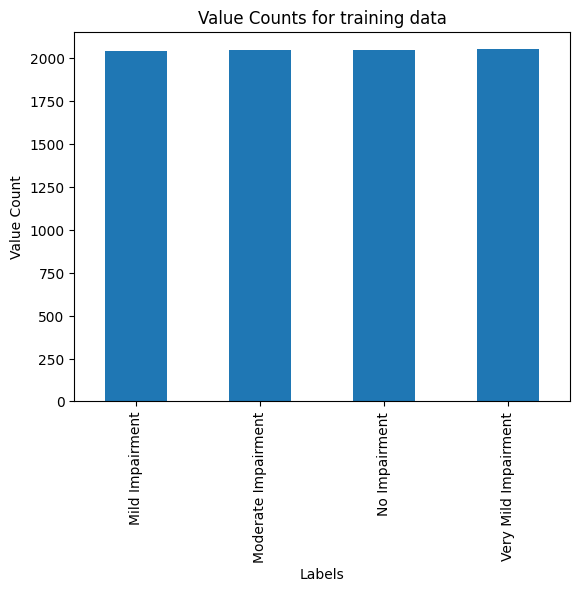

In [227]:
train_count.sort_values().plot(kind="bar")
plt.title("Value Counts for training data")
plt.xlabel("Labels")
plt.ylabel("Value Count")

100%|██████████| 2048/2048 [00:13<00:00, 152.30it/s]


Text(0, 0.5, 'Value Count')

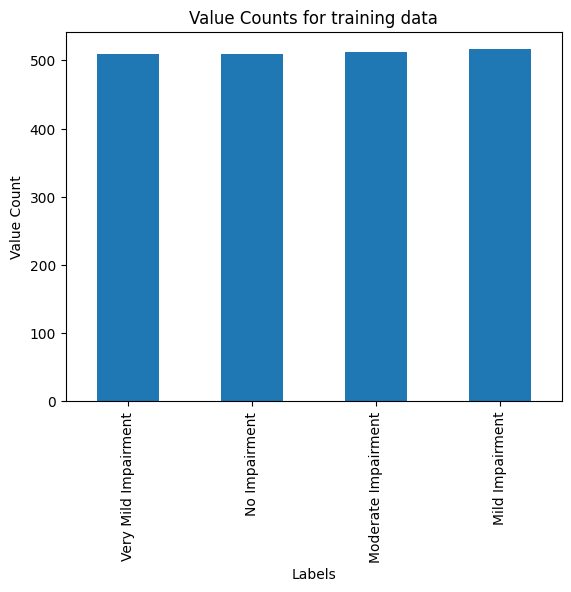

In [228]:
val_count=class_counts(val_data)
val_count.sort_values().plot(kind="bar")
plt.title("Value Counts for training data")
plt.xlabel("Labels")
plt.ylabel("Value Count")

In [229]:
train_loader= DataLoader(train_data,batch_size=batch_size,shuffle=True,generator=g)
val_loader=DataLoader(val_data,batch_size=batch_size,generator=g)

In [230]:
train_batch=next(iter(train_loader))[0]
train_batch.shape

torch.Size([32, 3, 224, 224])

In [231]:
model = torch.nn.Sequential(

    torch.nn.Conv2d(3,32,3,padding=1),
    torch.nn.BatchNorm2d(32),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2,2),

    torch.nn.Conv2d(32,64,3,padding=1),
    torch.nn.BatchNorm2d(64),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2,2),

    torch.nn.Conv2d(64,128,3,padding=1),
    torch.nn.BatchNorm2d(128),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2,2),

    torch.nn.Conv2d(128,256,3,padding=1),
    torch.nn.BatchNorm2d(256),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2,2),

   torch.nn.AdaptiveAvgPool2d((1,1)),

    torch.nn.Flatten(),

    torch.nn.Dropout(0.3),

    # Fully Connected Layers
    torch.nn.Linear(256,64),

    torch.nn.ReLU(),

    torch.nn.Linear(64,4)
)

In [232]:
height,width=224,224
summary(model,input_size=(batch_size,3,height,width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 4]                   --
├─Conv2d: 1-1                            [32, 32, 224, 224]        896
├─BatchNorm2d: 1-2                       [32, 32, 224, 224]        64
├─ReLU: 1-3                              [32, 32, 224, 224]        --
├─MaxPool2d: 1-4                         [32, 32, 112, 112]        --
├─Conv2d: 1-5                            [32, 64, 112, 112]        18,496
├─BatchNorm2d: 1-6                       [32, 64, 112, 112]        128
├─ReLU: 1-7                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-8                         [32, 64, 56, 56]          --
├─Conv2d: 1-9                            [32, 128, 56, 56]         73,856
├─BatchNorm2d: 1-10                      [32, 128, 56, 56]         256
├─ReLU: 1-11                             [32, 128, 56, 56]         --
├─MaxPool2d: 1-12                        [32, 128, 28, 28]         --
├─Co

In [233]:
y_train = [dataset_norm[i][1] for i in train_data.indices]
y_train = np.array(y_train)

In [234]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = np.clip(weights, 1.0, 10.0)
class_weights = torch.FloatTensor(weights).to(device="cuda")

In [235]:
print(weights)

[1.00195695 1.00048852 1.         1.        ]


In [236]:
lossfn=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [237]:
def train_epoch(model,optimizer,lossfn,data_loader,device="cuda"):
    training_losses=0.0
    model.train()
    for inputs,targets in tqdm.tqdm(data_loader,desc="Training",leave=False):
        optimizer.zero_grad()
        inputs=inputs.to(device)
        targets=targets.to(device)
        output=model(inputs)
        loss=lossfn(output,targets)
        loss.backward()
        optimizer.step()
        training_losses+=loss.data.item()
    return training_losses/len(data_loader)

In [239]:
loss_value=train_epoch(model,optimizer,lossfn,train_loader,device="cuda")
print(f"The average loss during the training epoch was {loss_value:.2f}")

The average loss during the training epoch was 0.86


In [208]:
def predict(model,data_loader,device="cuda"):
    model.eval()
    all_probs=[]
    with torch.no_grad():
        for inputs,labels in tqdm.tqdm(data_loader,desc="Training",leave=False):
            inputs=inputs.to(device)
            outputs=model(inputs)
            probs=F.softmax(outputs,dim=1)
            all_probs.append(probs)
    return torch.cat(all_probs,dim=0)

In [209]:
new_train_loader=DataLoader(train_data,batch_size=batch_size,shuffle=False)

In [210]:
probabilities_train=predict(model,new_train_loader,device="cuda")
probabilities_train.shape

torch.Size([8192, 4])

In [211]:
probabilities_val=predict(model,val_loader,device="cuda")
probabilities_val.shape

torch.Size([2048, 4])

In [212]:
print(probabilities_val[1])

tensor([2.7064e-05, 9.9787e-01, 1.3865e-03, 7.2095e-04], device='cuda:0')


In [213]:
print(probabilities_val[0].sum())

tensor(1., device='cuda:0')


In [214]:
predictions_train = torch.argmax(probabilities_train,dim=1)

In [215]:
prediction_val=torch.argmax(probabilities_val,dim=1)
print(prediction_val[:10])

tensor([1, 1, 2, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')


In [216]:
def score(predictions,data_loader,device="cuda"):
    targets=torch.cat([labels for _,labels in data_loader]).to(device)
    correct=(targets==predictions).sum().item()
    accuracy=correct/len(data_loader.dataset)
    return accuracy

In [217]:
train_score=score(predictions_train,new_train_loader,device="cuda")

In [218]:
print(f"The Training accuracy:{train_score}")

The Training accuracy:0.3074951171875


In [219]:
val_score=score(prediction_val,val_loader,device="cuda")

In [220]:
print(f"The validation accuracy:{val_score}")

The validation accuracy:0.31103515625


In [205]:
target_val=torch.cat([labels for _,labels in val_loader])
from sklearn.metrics import precision_score,f1_score,recall_score
Precision_score=precision_score(target_val.cpu(),prediction_val.cpu(),average="macro")
print("Precision score:",Precision_score)
f1=f1_score(target_val.cpu(),prediction_val.cpu(),average="macro")
print("F1 Score:",f1)
recall=recall_score(target_val.cpu(),prediction_val.cpu(),average="macro")
print("Recall Score:",recall)

Precision score: 0.7958169863411799
F1 Score: 0.4210434536498354
Recall Score: 0.5191789682447439
